In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [10]:
X_linear, y_linear = make_blobs(n_samples=100, centers=2, n_features=2, random_state=42, cluster_std=1.5)

X_nao_linear, y_nao_linear = make_moons(n_samples=100, noise=0.1, random_state=42)

In [11]:
def testar_modelo(nome, modelo, X, y):
    modelo.fit(X, y)
    pred = modelo.predict(X)

    tabela = pd.DataFrame({
        "x1": X[:, 0],
        "x2": X[:, 1],
        "esperado": y,
        "previsto": pred
    })

    print(f"\n=== {nome} ===")
    print(tabela.head(10))
    print(f"...\nAcurácia: {accuracy_score(y, pred):.2f}")

    return modelo

In [12]:
perceptron_linear = Perceptron(
    max_iter=20,
    eta0=0.1,
    tol=None,
    shuffle=False,
    random_state=42
)

testar_modelo("Perceptron - Dados Lineares", perceptron_linear, X_linear, y_linear)


=== Perceptron - Dados Lineares ===
         x1         x2  esperado  previsto
0 -3.227959   8.735798         0         0
1  6.264456   3.553873         1         1
2 -3.325772   9.180670         0         0
3  5.872969   4.818359         1         1
4  4.981069   3.933884         1         1
5 -1.967104  11.321341         0         0
6  5.054915   3.213945         1         1
7  2.313884   2.076014         1         1
8 -3.097360   6.819014         0         0
9 -3.768024   8.550468         0         0
...
Acurácia: 1.00


Perceptron(eta0=0.1, max_iter=20, random_state=42, shuffle=False, tol=None)

In [13]:
perceptron_nao_linear = Perceptron(
    max_iter=20,
    eta0=0.1,
    tol=None,
    shuffle=False,
    random_state=42
)

testar_modelo("Perceptron - Dados Não-Lineares", perceptron_nao_linear, X_nao_linear, y_nao_linear)


=== Perceptron - Dados Não-Lineares ===
         x1        x2  esperado  previsto
0  1.582023 -0.445815         1         1
1  0.066045  0.439207         1         1
2  0.736631 -0.398963         1         1
3 -1.056928  0.242456         0         0
4 -0.802162  0.202718         0         1
5 -0.706413  0.770762         0         0
6  0.205388  0.818753         0         1
7  1.378050 -0.446580         1         1
8  0.848193  0.671723         0         1
9  0.922030 -0.084390         0         1
...
Acurácia: 0.76


Perceptron(eta0=0.1, max_iter=20, random_state=42, shuffle=False, tol=None)

In [14]:
mlp_nao_linear = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation="logistic",
    solver="lbfgs",
    max_iter=10000,
    random_state=42
)

testar_modelo("MLP - Dados Não-Lineares", mlp_nao_linear, X_nao_linear, y_nao_linear)


=== MLP - Dados Não-Lineares ===
         x1        x2  esperado  previsto
0  1.582023 -0.445815         1         1
1  0.066045  0.439207         1         1
2  0.736631 -0.398963         1         1
3 -1.056928  0.242456         0         0
4 -0.802162  0.202718         0         0
5 -0.706413  0.770762         0         0
6  0.205388  0.818753         0         0
7  1.378050 -0.446580         1         1
8  0.848193  0.671723         0         0
9  0.922030 -0.084390         0         1
...
Acurácia: 0.91


MLPClassifier(activation='logistic', hidden_layer_sizes=(4,), max_iter=10000,
              random_state=42, solver='lbfgs')

In [15]:
import matplotlib.pyplot as plt

def desenhar_rede_mlp(modelo):
    camadas = [modelo.n_features_in_]

    if isinstance(modelo.hidden_layer_sizes, int):
        camadas.append(modelo.hidden_layer_sizes)
    else:
        camadas.extend(modelo.hidden_layer_sizes)

    camadas.append(modelo.n_outputs_)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis("off")

    x_positions = list(range(len(camadas)))

    neuron_positions = []

    for camada_idx, n_neuronios in enumerate(camadas):
        y_positions = []

        for i in range(n_neuronios):
            y = (n_neuronios - 1) / 2 - i
            y_positions.append(y)

            if camada_idx == 0:
                label = f"x{i+1}"
            elif camada_idx == len(camadas) - 1:
                label = "y"
            else:
                label = f"h{i+1}"

            circle = plt.Circle((camada_idx, y), 0.12, fill=False, linewidth=2)
            ax.add_patch(circle)
            ax.text(camada_idx, y, label, ha="center", va="center", fontsize=10)

        neuron_positions.append(y_positions)

    for camada_idx, W in enumerate(modelo.coefs_):
        for i in range(W.shape[0]):
            for j in range(W.shape[1]):
                x1 = camada_idx
                y1 = neuron_positions[camada_idx][i]
                x2 = camada_idx + 1
                y2 = neuron_positions[camada_idx + 1][j]

                peso = W[i, j]

                ax.plot([x1, x2], [y1, y2], linewidth=1)

                xm = (x1 + x2) / 2
                ym = (y1 + y2) / 2
                ax.text(xm, ym, f"{peso:.2f}", fontsize=8,
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8))

    for camada_idx, b in enumerate(modelo.intercepts_, start=1):
        for j, bias in enumerate(b):
            x = camada_idx
            y = neuron_positions[camada_idx][j]
            ax.text(x + 0.18, y, f"b={bias:.2f}", fontsize=8, color="darkred")

    ax.set_title("Rede MLP treinada", fontsize=14)
    plt.show()

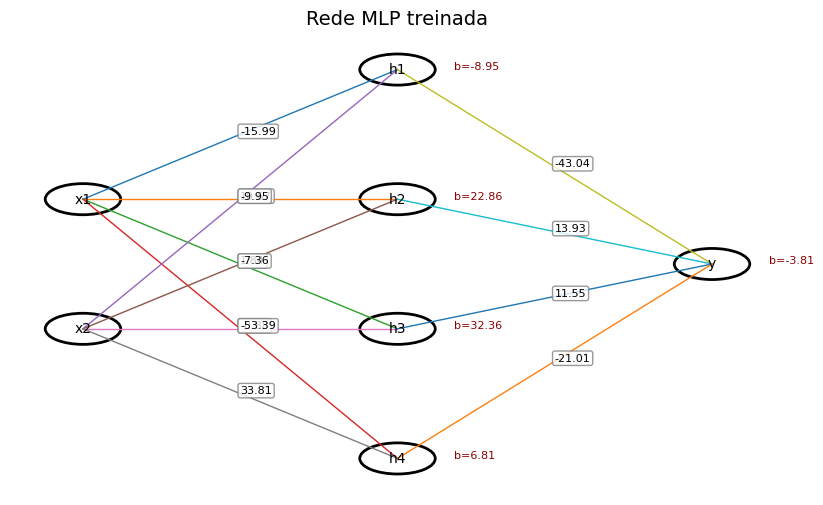

In [16]:
desenhar_rede_mlp(mlp_nao_linear)

In [17]:
probs = mlp_nao_linear.predict_proba(X_nao_linear)[:5]
predicoes = mlp_nao_linear.predict(X_nao_linear)[:5]

print("x1          x2         | classe esperada | classe prevista | probabilidades")
print("-----------------------------------------------------------------------------")

for entrada, esperado, previsto, prob in zip(X_nao_linear[:5], y_nao_linear[:5], predicoes, probs):
    print(f"{entrada[0]:.4f}  {entrada[1]:.4f}  |       {esperado}         |        {previsto}        | {prob}")

x1          x2         | classe esperada | classe prevista | probabilidades
-----------------------------------------------------------------------------
1.5820  -0.4458  |       1         |        1        | [3.87357701e-10 1.00000000e+00]
0.0660  0.4392  |       1         |        1        | [0.33943991 0.66056009]
0.7366  -0.3990  |       1         |        1        | [3.92208488e-10 1.00000000e+00]
-1.0569  0.2425  |       0         |        0        | [1.00000000e+00 4.70406882e-19]
-0.8022  0.2027  |       0         |        0        | [1.00000000e+00 1.32927941e-16]
